dt = 172.69303206108668
Simulação com 868 passos de tempo


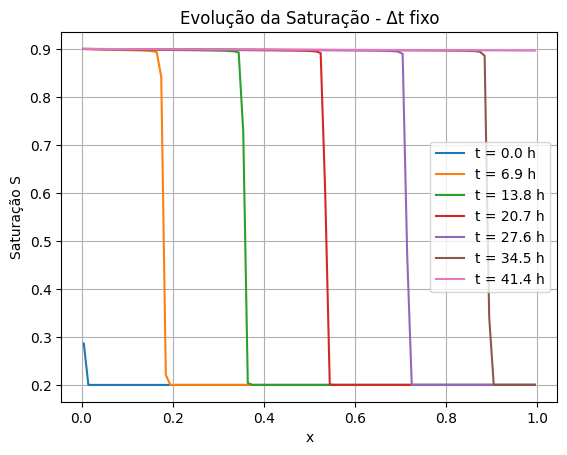

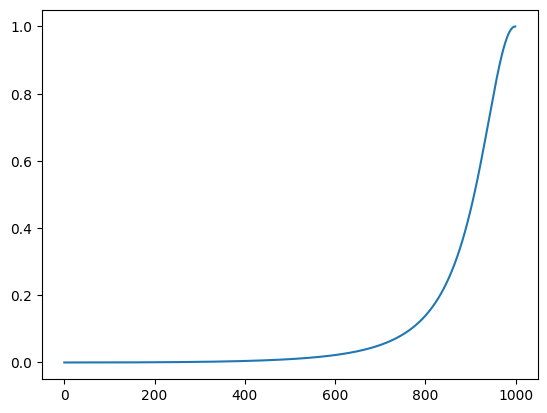

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Parâmetros
L = 1.0
Nx = 100
dx = L / Nx
phi = 0.2
u = 1e-6
mu_w = 1e-3
mu_g = 1e-5
S_wc = 0.2
S_gr = 0.1

# Funções
def S_n(S):
    return (S - S_wc) / (1 - S_wc - S_gr)

def k_rw(S):
    Sn = S_n(S)
    return Sn**2

def k_rg(S):
    Sn = S_n(S)
    return (1 - Sn)**2

def f_w(S):
    krw = k_rw(S)
    krg = k_rg(S)
    return krw / (krw + (mu_w/mu_g) * krg)

def f(S):
    return u * f_w(S)

# Malha
x = np.linspace(dx/2, L - dx/2, Nx)
S = np.full(Nx, 0.2)  # Saturação inicial
S_left = 0.9  # Saturação injetada


#Condião CFL
cfl = 0.9
S_lambda = np.linspace(S_wc, 1-S_gr, 1000)
df_ds = np.gradient(f(S_lambda), S_lambda[1]-S_lambda[0])
vel_lambda = df_ds / phi
dt = cfl * dx / np.max(vel_lambda)
T_max = 150000
Nt = int(T_max / dt)
print (f'dt = {dt}')

'''

# Tempo Δt fixo
dt = 1.0  # Segundos - valor conservador
T_max = 150000  # Segundos totais
Nt = int(T_max / dt)

'''

print(f"Simulação com {Nt} passos de tempo")

# Loop temporal simples
for n in range(Nt):
    t = n * dt

    # Fluxos nas interfaces (upwind)
    F = np.zeros(Nx + 1)
    F[0] = f(S_left)  # Entrada

    for i in range(Nx):
        F[i+1] = f(S[i])  # Upwind: F_{i+1/2} = f(S_i)

    #Forma explícita
    S = S - (dt / (phi * dx)) * (F[1:] - F[:-1])

    if n % int(Nt/6) == 0:  # Plot a cada 2000 passos
        plt.plot(x, S, label=f't = {t/3600:.1f} h')

plt.xlabel('x')
plt.ylabel('Saturação S')
plt.title('Evolução da Saturação - Δt fixo')
plt.legend()
plt.grid(True)
plt.show()


plt.plot(f_w(S_lambda))
